In [ ]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv("adult_income.csv")

# Clean categorical columns
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()


## Univariate Visualisations

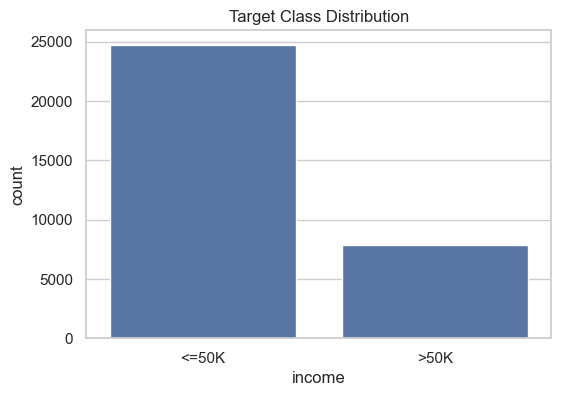

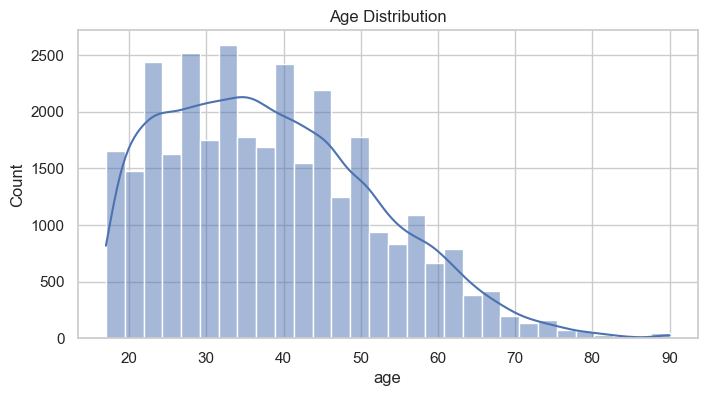

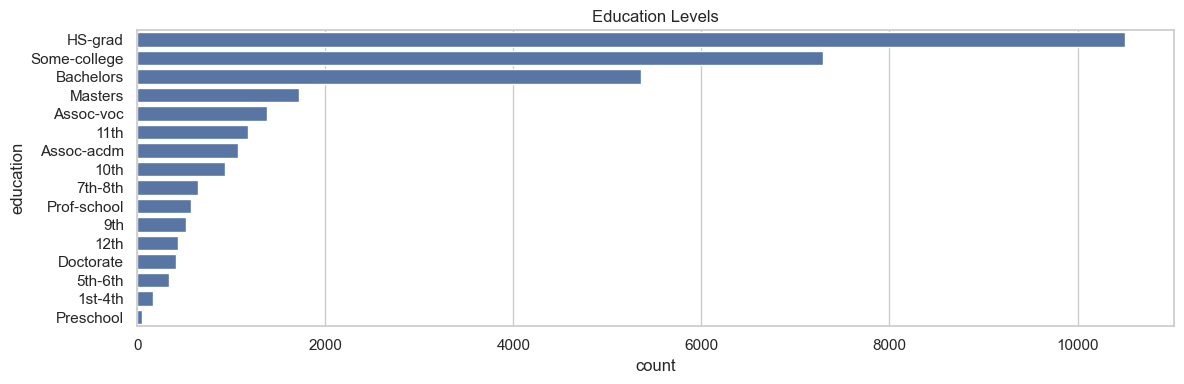

In [2]:
# 🎯 Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df)
plt.title("Target Class Distribution")
plt.show()

# 📈 Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

# 📚 Education levels
plt.figure(figsize=(12, 4))
sns.countplot(data=df, y='education', order=df['education'].value_counts().index)
plt.title("Education Levels")
plt.tight_layout()
plt.show()


## BiVariate Visualizations

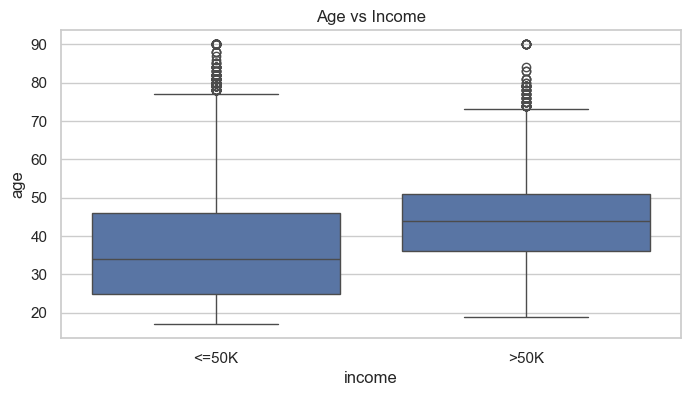

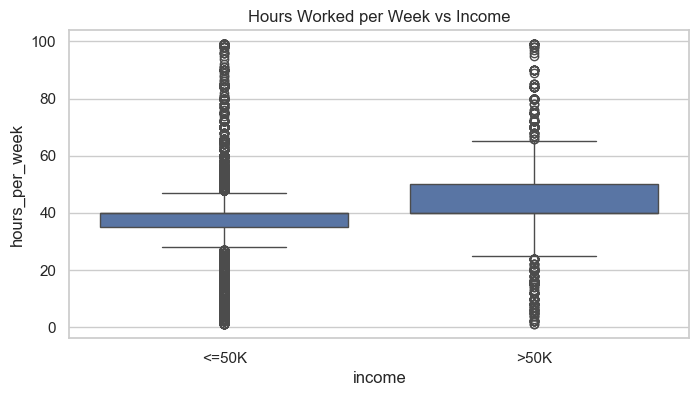

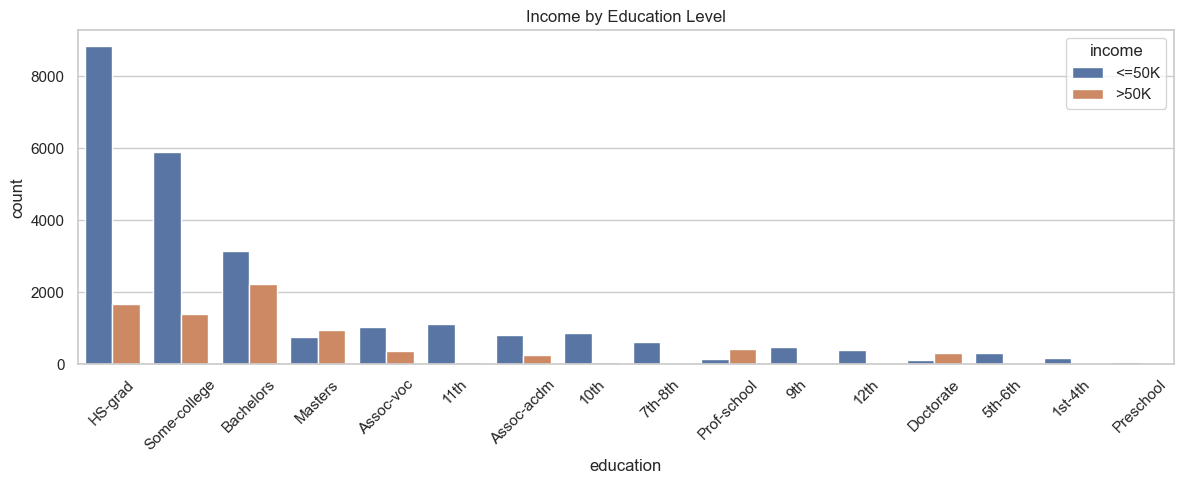

In [3]:
# Age vs Income (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
plt.show()

# Hours-per-week vs Income
plt.figure(figsize=(8, 4))
sns.boxplot(x='income', y='hours_per_week', data=df)
plt.title("Hours Worked per Week vs Income")
plt.show()

# Education vs Income (Count plot)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='education', hue='income', order=df['education'].value_counts().index)
plt.title("Income by Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Multivariate Visualizations

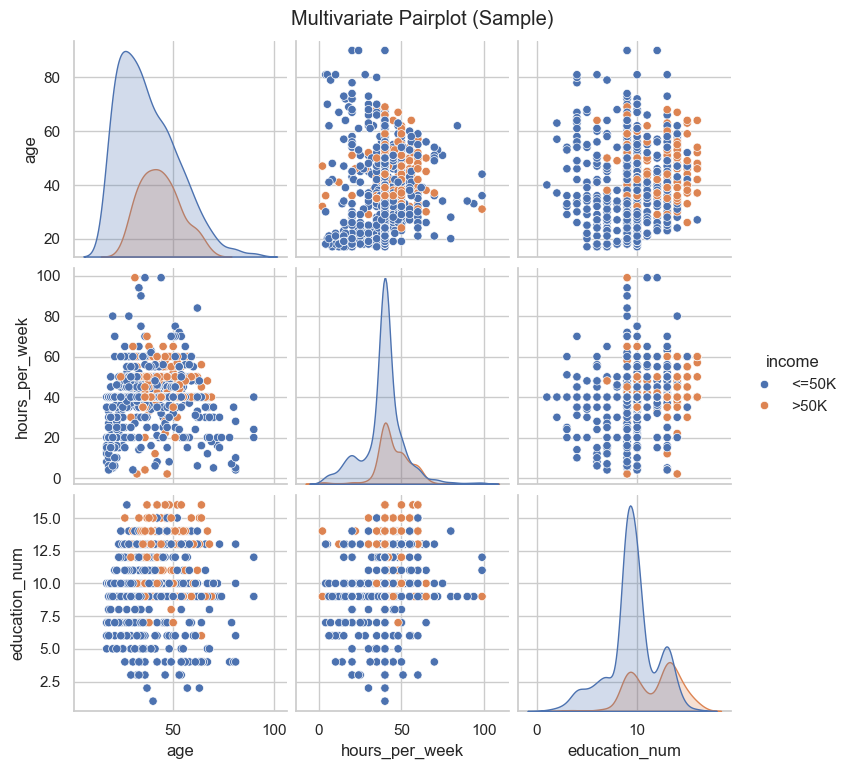

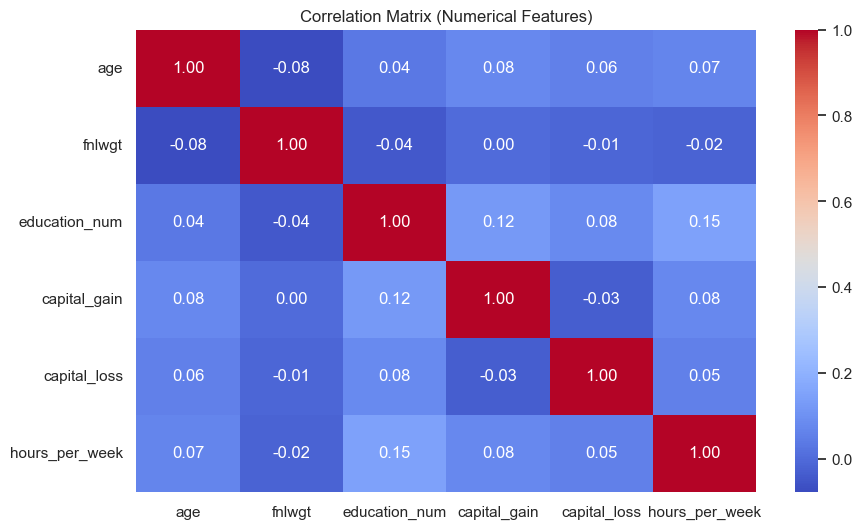

In [4]:
# Pairplot with selected features
sample_df = df.sample(n=1000, random_state=42)  # Reduce size for faster rendering
sns.pairplot(sample_df, hue='income', vars=['age', 'hours_per_week', 'education_num'])
plt.suptitle("Multivariate Pairplot (Sample)", y=1.02)
plt.show()

# Correlation heatmap (numeric)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()


## Categorical Visualizations

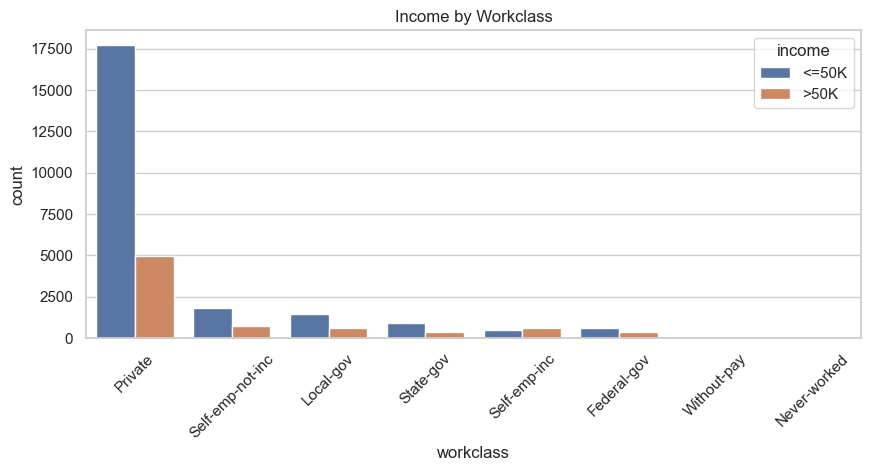

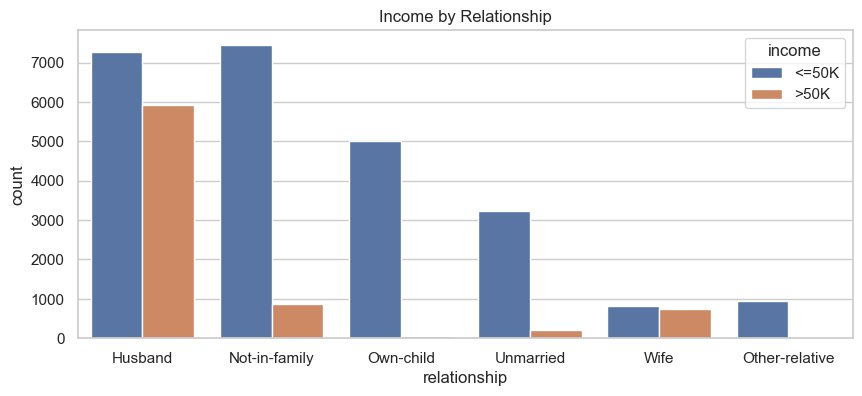

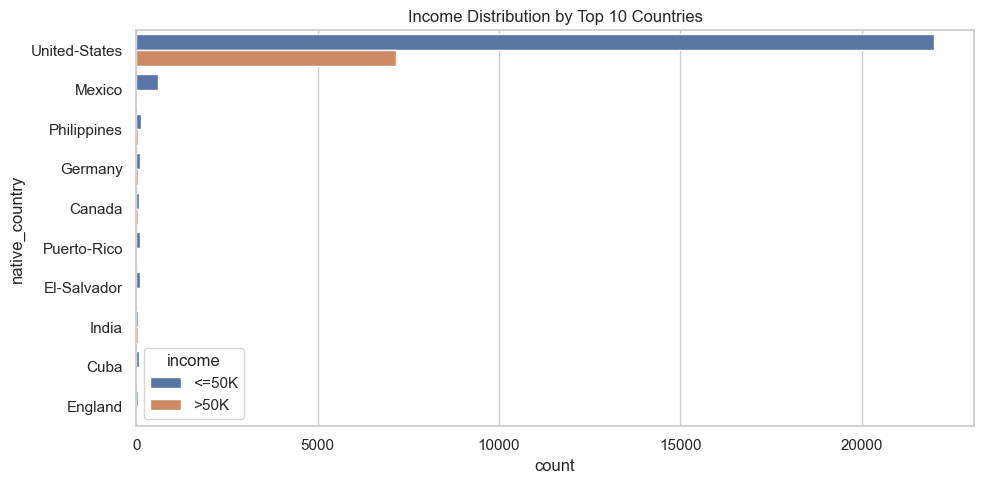

In [5]:
# Workclass vs Income
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='workclass', hue='income', order=df['workclass'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Income by Workclass")
plt.show()

# Relationship vs Income
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='relationship', hue='income', order=df['relationship'].value_counts().index)
plt.title("Income by Relationship")
plt.show()

# Native Country (Top 10)
top_countries = df['native_country'].value_counts().nlargest(10).index
filtered_df = df[df['native_country'].isin(top_countries)]

plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, y='native_country', hue='income', order=top_countries)
plt.title("Income Distribution by Top 10 Countries")
plt.tight_layout()
plt.show()


## More

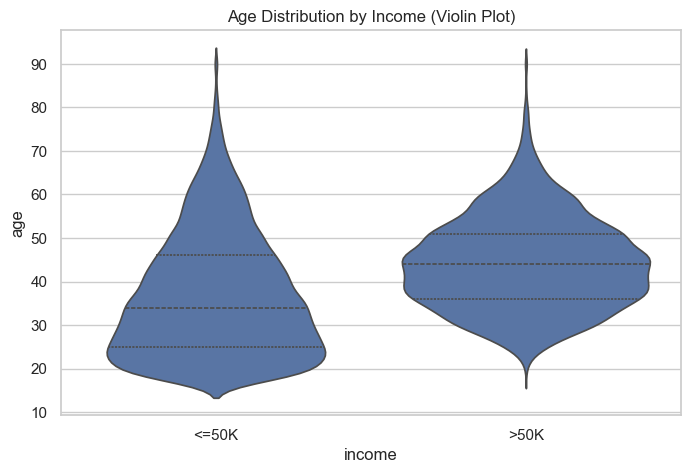

In [6]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='income', y='age', inner='quartile')
plt.title("Age Distribution by Income (Violin Plot)")
plt.show()


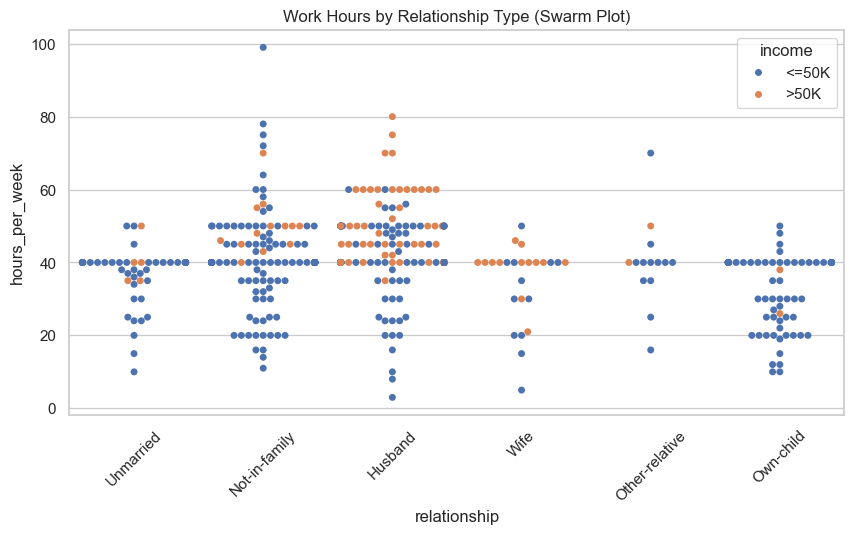

In [7]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.swarmplot(data=df.sample(500), x='relationship', y='hours_per_week', hue='income')
plt.title("Work Hours by Relationship Type (Swarm Plot)")
plt.xticks(rotation=45)
plt.show()


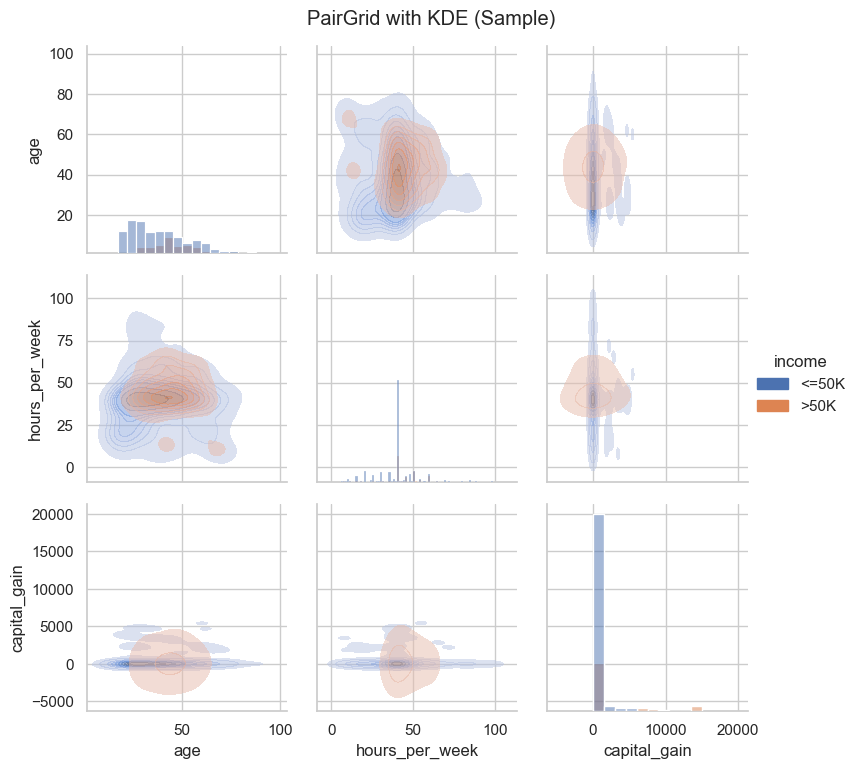

In [9]:
g = sns.PairGrid(df.sample(500), hue='income', vars=['age', 'hours_per_week', 'capital_gain'])
g.map_diag(sns.histplot)
g.map_offdiag(sns.kdeplot, fill=True, alpha=0.5)
g.add_legend()
g.fig.suptitle("PairGrid with KDE (Sample)", y=1.02)
plt.show()


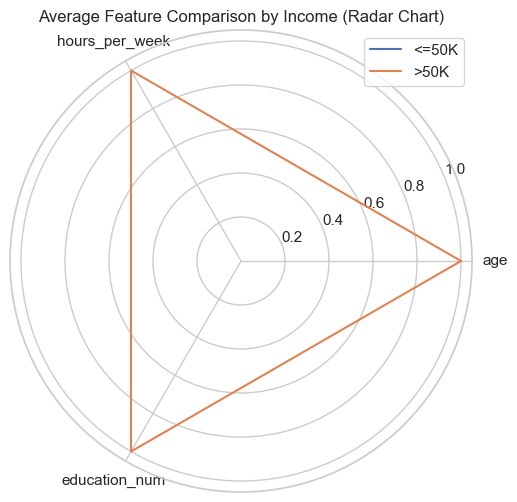

In [10]:
import numpy as np

# Compare average normalized stats between income groups
radar_data = df.groupby('income')[['age', 'hours_per_week', 'education_num']].mean()
radar_data = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

categories = radar_data.columns.tolist()
labels = ['<=50K', '>50K']
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # complete loop

plt.figure(figsize=(6, 6))
for i, label in enumerate(labels):
    values = radar_data.iloc[i].tolist()
    values += values[:1]
    plt.polar(angles, values, label=label)

plt.xticks(angles[:-1], categories)
plt.title("Average Feature Comparison by Income (Radar Chart)")
plt.legend(loc='upper right')
plt.show()
